In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loan_df = pd.read_csv('loan_approval_dataset.csv')

# all columns start with the space. Fix needed
for col in loan_df.columns:
    if col.startswith(' '):
        loan_df = loan_df.rename(columns={col: col[1:]})

# loan status: if approved then 1 if approved; 0 if rejected
loan_df['loan_status'] = loan_df['loan_status'].apply(lambda status: 1 if status.lower() == ' approved' else 0)

# education: if graduated then 1 else 0
loan_df['education'] = loan_df['education'].apply(lambda education: 1 if education.lower() == ' graduate' else 0)

# self_employed: if self employed then 1; else 0
loan_df['self_employed'] = loan_df['self_employed'].apply(lambda s: 1 if s.lower() == ' yes' else 0)








In [2]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   int64
 3   self_employed             4269 non-null   int64
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   int64
dtypes: int64(13)
memory usage: 433.7 KB


In [3]:
loan_df.describe()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2135.000000,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1232.498479,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,1.000000,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1068.000000,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,2135.000000,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,3202.000000,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,4269.000000,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


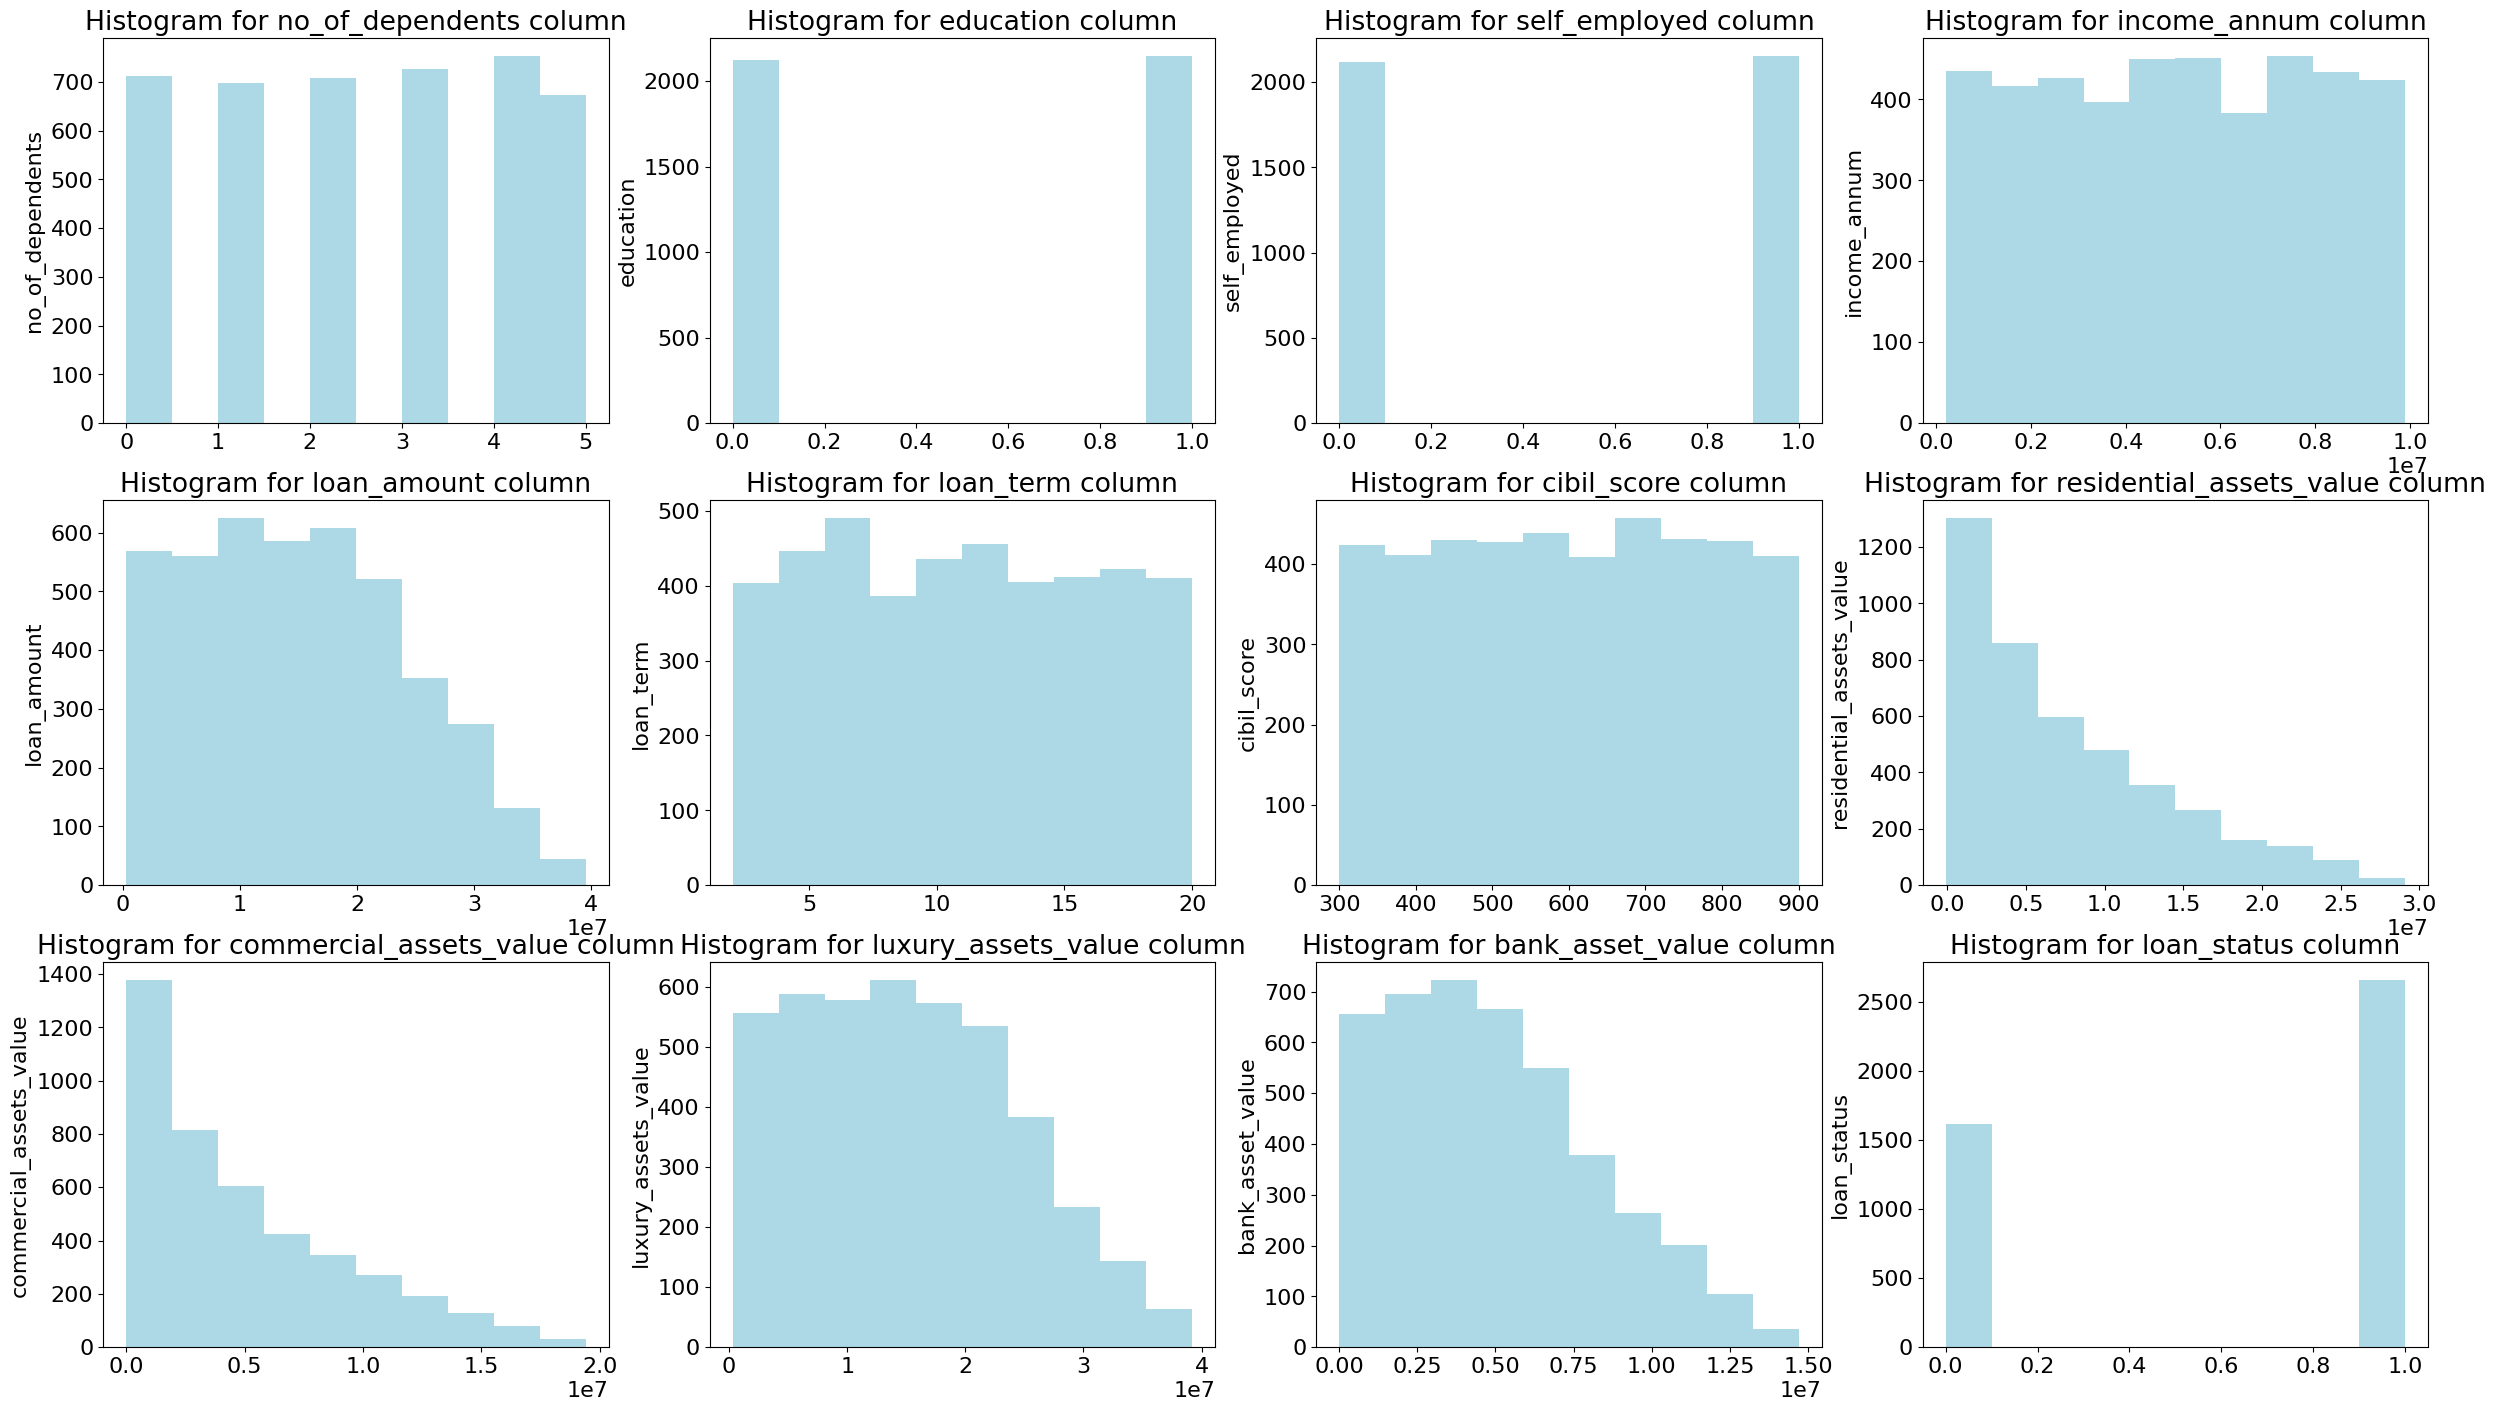

In [4]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(3, 4, figsize=(30, 17))
i = 0
j = 0
numeric_cols = []

for col in loan_df.columns:
    
    if col != 'loan_id':
        numeric_cols.append(col)
        ax[i, j].hist(loan_df[col].dropna(), color='lightblue') 
        ax[i, j].set_title(f'Histogram for {col} column')
        ax[i, j].set_ylabel(col)
        j += 1
        if j > 3:
            j = 0
            i += 1

plt.savefig('distributions.png')
plt.show()

# classes are unbalanced (target variable)


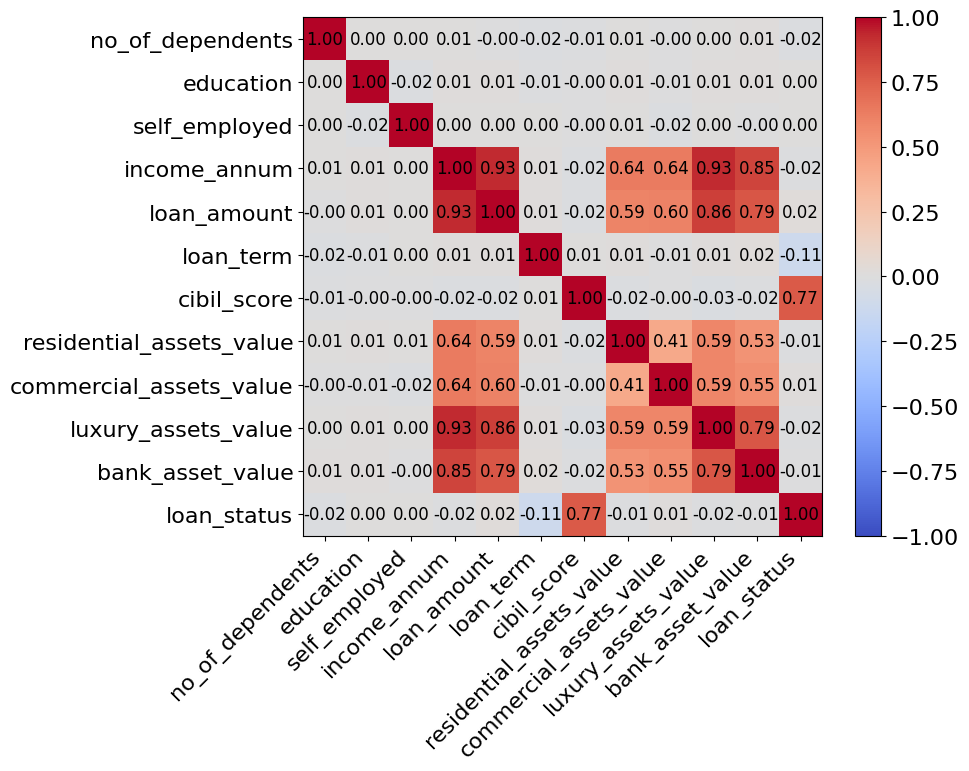

In [5]:
corr = loan_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
# ax.set_title('Correlation matrix')
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iat[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

# cibil score; loan term; income_annum; 



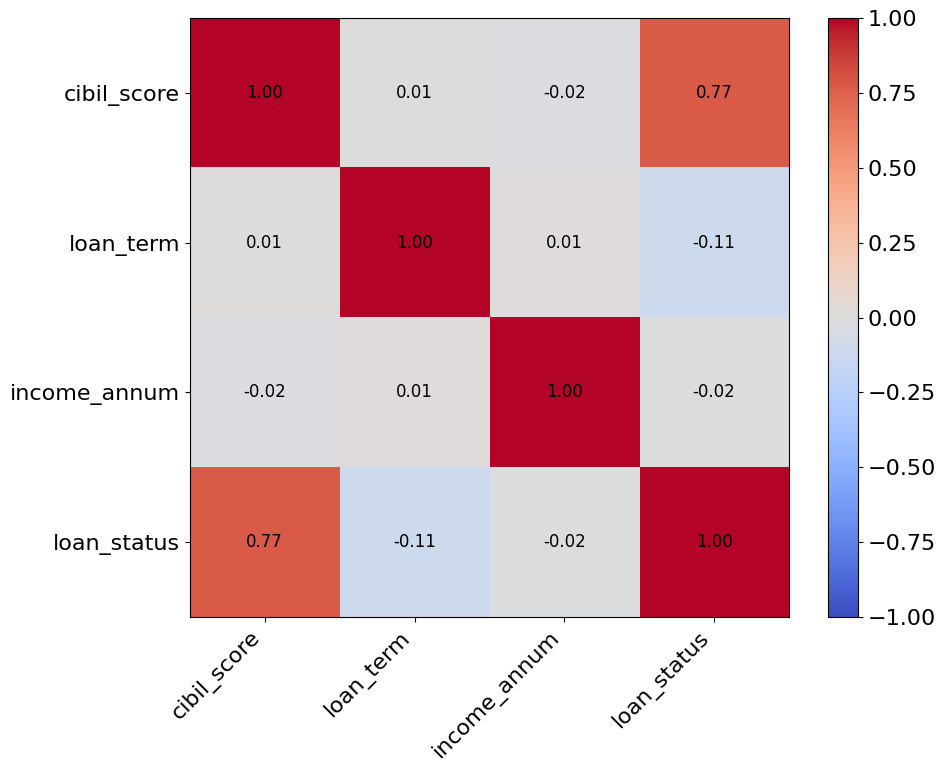

In [6]:
prediction_df = loan_df[['cibil_score', 'loan_term', 'income_annum', 'loan_status']]

corr_2 = prediction_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_2, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_2.columns)))
ax.set_yticks(range(len(corr_2.columns)))
ax.set_xticklabels(corr_2.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_2.columns)
# ax.set_title('Correlation matrix')
for i in range(corr_2.shape[0]):
    for j in range(corr_2.shape[1]):
        val = corr_2.iat[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.savefig('correlation_matrix_2')
plt.show()




In [7]:
# balance classes
min_count = prediction_df['loan_status'].value_counts().min()
df_0 = prediction_df[prediction_df['loan_status'] == 0].sample(n=min_count, random_state=42)
df_1 = prediction_df[prediction_df['loan_status'] == 1].sample(n=min_count, random_state=42)

prediction_df = pd.concat([df_0, df_1]).sample(frac=1, random_state=42).reset_index(drop=True)

train_fraction = 0.8

df_0 = prediction_df[prediction_df['loan_status'] == 0]
train_0 = df_0.sample(frac=train_fraction, random_state=42)
test_0 = df_0.drop(train_0.index)

df_1 = prediction_df[prediction_df['loan_status'] == 1]
train_1 = df_1.sample(frac=train_fraction, random_state=42)
test_1 = df_1.drop(train_1.index)

train_df = pd.concat([train_0, train_1]).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=42).reset_index(drop=True)

input_data_train = train_df[['cibil_score', 'loan_term', 'income_annum']]
output_data_train = train_df['loan_status']

input_data_test = test_df[['cibil_score', 'loan_term', 'income_annum']]
output_data_test = test_df['loan_status']

optimal number of neighbours is 1
Optimal error is 0.07945736434108519


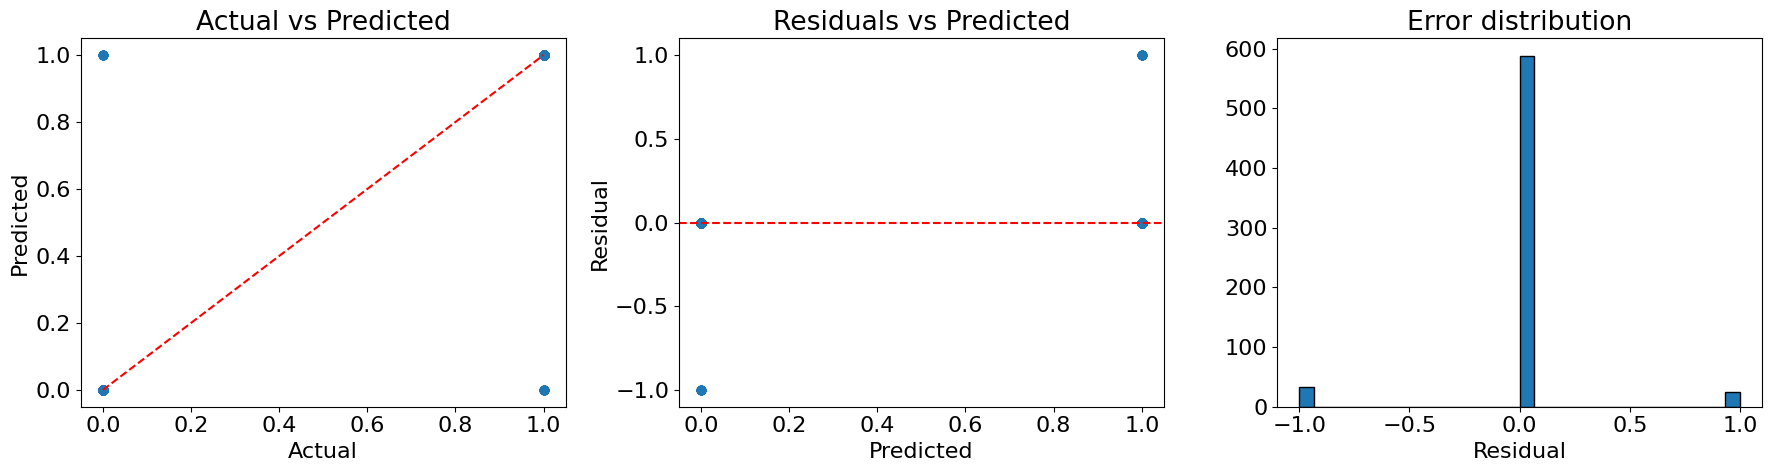

Accuracy: 0.910
False Positive Rate (FPR): 0.077
False Negative Rate (FNR): 0.102
Precision: 0.921
Recall: 0.898


In [17]:
# KNN
# this is a more explicit alternative of the same code
def pairwise_distances(from_data, to_data):
    return np.sqrt(np.sum((from_data[:, np.newaxis, :] - to_data[np.newaxis, :, :])**2,axis=2))

# we can put all together!
def nearest_neighbour_classification(testing_inputs, training_inputs,training_outputs, no_of_neighbours):
    
    # first thing is to compute pairwise distances
    distances = pairwise_distances(testing_inputs, training_inputs)
    
    no_of_classes = 1 + np.max(training_outputs)
    sorted_indices = np.argsort(distances, axis=1)
    
    no_of_inputs = len(testing_inputs) # these are the data that we are trying to classify
    no_of_points = len(training_inputs)
    
    new_array_to_sort = np.broadcast_to(training_outputs,(no_of_inputs, no_of_points))
    sorted_labels = np.take_along_axis(new_array_to_sort,sorted_indices, 1)
    
    predicted_labels=np.zeros(no_of_inputs,int)
    for id_input in range(no_of_inputs):
        
        probability_labels=np.zeros(no_of_classes,float)
        
        for id_neighbor in range(0,no_of_neighbours):
            probability_labels[sorted_labels[id_input][id_neighbor]]+=1./no_of_neighbours

        predicted_labels[id_input]=np.argmax(probability_labels)
    
    
    return predicted_labels

def classification_accuracy(estimated_labels, true_labels):
    equal_labels = estimated_labels == true_labels
    return np.mean(equal_labels) 

def KFold_split(data_size, K):
    np.random.seed(123456789)
    indexes = np.random.permutation(data_size)
    m, r = divmod(data_size, K)
    indexes_split = [
        indexes[i * m + min(i, r):(i + 1) * m + min(i + 1, r)]
        for i in range(K)
    ]
    return indexes_split


def KFold_cross_validation_knn(data_inputs, data_outputs, K, labels_evaluation,
                           missclassification_evaluation,knn):
    
    data_size = len(data_inputs)
    indexes_split = KFold_split(data_size, K)

    average_accuracy = 0
    for i in range(K):
        training_indexes = np.concatenate([indexes_split[j] for j in range(K) if (j != i)])
        
        predicted_labels = labels_evaluation(data_inputs[indexes_split[i]],
                                             data_inputs[training_indexes],
                                             data_outputs[training_indexes],knn)
        
        accuracy = missclassification_evaluation(predicted_labels,
                                              data_outputs[indexes_split[i]])
        average_accuracy += accuracy / K
        
    error = 1.-average_accuracy
    return error

def grid_search(objective, grid):
    values = np.array([])
    for point in grid:
        values = np.append(values, objective(point))
    return grid[np.argmin(values)]

n_true = 0
K = 1

for i in range(1, 20):
    y_knn = nearest_neighbour_classification(
        testing_inputs=input_data_test.to_numpy(),
        training_inputs=input_data_train.to_numpy(),
        training_outputs=output_data_train.to_numpy(),
        no_of_neighbours=i
    )
    n_true_current = classification_accuracy(y_knn, output_data_test)
    if n_true_current > n_true:
        n_true = n_true_current
        K = i

evaluation = lambda testing_data_inputs,training_data_inputs, training_data_outputs, k: nearest_neighbour_classification(testing_data_inputs,training_data_inputs,training_data_outputs,no_of_neighbours=k)

missclassification_evaluation= lambda predicted_labels,true_labels: classification_accuracy(predicted_labels,true_labels)

K=5
data_size = len(input_data_train)
Knn = list(range(1,21,1))
K_objective_function = lambda k: KFold_cross_validation_knn(input_data_train.to_numpy(), output_data_train.to_numpy(), K,evaluation, missclassification_evaluation,k)

optimal_no_of_neighbours = grid_search(K_objective_function, Knn)
optimal_classification_error = K_objective_function(optimal_no_of_neighbours)
print(f"optimal number of neighbours is {optimal_no_of_neighbours}")
print(f"Optimal error is {optimal_classification_error}")
# K = 3 is optimal
y_knn = nearest_neighbour_classification(
        testing_inputs=input_data_test.to_numpy(),
        training_inputs=input_data_train.to_numpy(),
        training_outputs=output_data_train.to_numpy(),
        no_of_neighbours=optimal_no_of_neighbours
)



y_pred_test = y_knn
y_test = output_data_test.to_numpy()
residuals_test = y_pred_test - y_test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5)
axes[0].plot([0,1], [0,1], 'r--')
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

axes[1].scatter(y_pred_test, residuals_test, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

axes[2].hist(residuals_test, bins=30, edgecolor='black')
axes[2].set_title("Error distribution")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.savefig('knn.png')
plt.show()

TP = np.sum((y_pred_test == 1) & (y_test == 1))
TN = np.sum((y_pred_test == 0) & (y_test == 0))
FP = np.sum((y_pred_test == 1) & (y_test == 0))
FN = np.sum((y_pred_test == 0) & (y_test == 1))

total = TP + TN + FP + FN

accuracy = (TP + TN) / total

false_positive_rate = FP / (FP + TN)     
false_negative_rate = FN / (FN + TP)      

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"Accuracy: {accuracy:.3f}")

print(f"False Positive Rate (FPR): {false_positive_rate:.3f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.3f}")

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")




